# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import gc
import os
import sys
import random
import wandb
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import fvdb_utils as fu
import model as fvdbModel
import unet as fvdbUnet
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure
import trimesh

# Args

In [2]:
pos_enc_dim=10
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'
ponq_data_dir = '/data/workspaces/spanwar/dataset/ponq_dataset/gt_Quadrics'

# Load DataSet

In [4]:
train_set_names = os.listdir(ponq_data_dir)[:150]

In [5]:
random.shuffle(train_set_names)
train_size = int(0.6 * len(train_set_names))
test_size = int(0.2 * len(train_set_names))
val_size = len(train_set_names) - train_size - test_size
train_names = train_set_names[:train_size]
val_names = train_set_names[train_size:train_size + val_size]
test_names = train_set_names[train_size + val_size:]

train_dataset = ABCdataset(ponq_data_dir, train_names)
val_dataset = ABCdataset(ponq_data_dir, val_names)
test_dataset = ABCdataset(ponq_data_dir, test_names, mode='test')

print(f'Number of samples in the dataset: {len(train_set_names)}')
print(f'Number of samples in the train set: {len(train_dataset)}')
print(f'Number of samples in the test set: {len(test_dataset)}')
print(f'Number of samples in the validation set: {len(val_dataset)}')

100%|██████████| 30/30 [00:00<00:00, 16413.92it/s]

Number of samples in the dataset: 150
Number of samples in the train set: 90
Number of samples in the test set: 30
Number of samples in the validation set: 30


In [6]:
# %reload_ext autoreload
train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')

# Load Model

In [7]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

In [8]:
model = fvdbUnet.FVDBUNetBase(in_channels=pos_enc_dim+2, out_channels=1)
model = model.to(device)

In [9]:
# model summary and parameters
def print_model_summary(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")
print_model_summary(model)
# show model architecture
print(model)

Total parameters: 21743649
Trainable parameters: 21743649
FVDBUNetBase(
  (conv0p1s1): SparseConv3d(12, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 3

# Train Model

In [10]:
def fm_sampling(output, noise, t):
    ouput_j = output.jdata
    noise_j = noise.jdata
    
    xt = ouput_j * t + noise_j * (1 - t)
    xt = fvnn.VDBTensor(output.grid, output.grid.jagged_like(xt))
    return xt

In [11]:
def additional_feature(input, t):
    '''add additional feature to the input'''
    input_j = input.jdata
    
    # add time as a feature
    # t_col = torch.ones_like(input_j[:, :1]) * t
    new_features = torch.cat([input_j, t], dim=1)
    return fvnn.VDBTensor(input.grid, input.grid.jagged_like(new_features))

In [12]:
def add_g_noise(vdb, t, noise_level=0.1):
    '''add noise to the small vdb'''
    
    # stochastic preconditioning
    noise = torch.randn_like(vdb.jdata) * noise_level * (1 - t)
    # noise = torch.randn_like(vdb.jdata)
    noisy_small_vdb = vdb.jdata + noise
    return fvnn.VDBTensor(vdb.grid, vdb.grid.jagged_like(noisy_small_vdb))

In [13]:
def transform_input(input, 
                    output, t, 
                    scale_factor=2, 
                    upsampler=None, 
                    g_noise=True,
                    test=False):
    # check upsampler args is one of 'nearest', 'trilinear', or None
    if upsampler is not None and not (isinstance(upsampler, str) and upsampler in ['nearest', 'trilinear']):
        raise ValueError("Upsampler must be a string: 'nearest', 'trilinear', or None.")

    if upsampler == 'nearest':
        upsampler = fvnn.UpsamplingNearest(scale_factor=scale_factor)
        upsample_input = upsampler(input)
    elif upsampler == 'trilinear':
        new_centers = output.grid.grid_to_world(output.ijk.float())
        upsample_data = input.grid.sample_trilinear(new_centers, input.data)
        upsample_input = fvnn.VDBTensor(output.grid, upsample_data)
    elif upsampler is None:
        upsample_input = input
    else:
        raise ValueError("Invalid upsampler type. Use 'nearest', 'trilinear', or None.")

    if upsampler is not None:
        # match the grid to the output grid
        gridFiller = fvnn.FillFromGrid()
        upsample_input = gridFiller(upsample_input, output.grid)
    
    # if keep_gt:
    #     to_change_idx = upsample_input.grid.ijk_to_index(
    #                             input.grid.ijk).jdata
    #     upsample_input.data.jdata[to_change_idx] = input.jdata

    if test is False:
        xt = fm_sampling(output, upsample_input, t)
    else:
        xt = upsample_input

    if g_noise:
        xt = add_g_noise(xt, t, noise_level=0.1)
        xt = positional_encoding(xt, pos_enc_dim)
        xt = additional_feature(xt, t)
        xt = xt
    elif not g_noise:
        xt = positional_encoding(xt, pos_enc_dim)
        xt = additional_feature(xt, t)
        xt = xt

    return xt, upsample_input

In [14]:
def fm_loss(pred_flow, target, noise):
    'calculate the flow matching loss'
    pred_flow = pred_flow.jdata
    target = target.jdata
    noise = noise.jdata
    # print(pred_flow.shape, target.shape, noise.shape)

    true_flow = target - noise
    return torch.mean((pred_flow - true_flow) ** 2)
    

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

# Train the Model

In [16]:
# wandb.init(project="SSU", entity="sp_kumar", name="SSU_PONQ_DATA_UPSAMPLER_FM_trilinear_Unet", config={
#     "Discpription": "Implementing Unet model and FM, train on PONQ Dataset.",
#     "batch_size": 1,
#     "learning_rate": 1e-3,
#     "epochs": 10,
#     "positional_encoding_dim": 10,
#     "model": "Unet",
#     "dataset": "PONQ Dataset",
#     "dataset_size": len(train_set_names),
#     "dataset_split": {
#         "train": len(train_dataset),
#         "val": len(val_dataset),
#         "test": len(test_dataset)
#     },
#     "model_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
#     "loss_function": "MSE loss",
#     "optimizer": "Adam",
#     "device": device
# })

In [23]:
def train(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    saliency_labels = ['sdf'] + [f'pos_enc_{i}' for i in range(pos_enc_dim)]
    saliency_feature = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        saliency_feature_epoch = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            batch_size = 1
            t = torch.rand_like(large_vdb.jdata).to(device)

            #transform vdb
            xt, noise = transform_input(small_vdb, 
                                        large_vdb, 
                                        t, 
                                        upsampler='trilinear', 
                                        g_noise=True)

            xt.jdata.requires_grad_()
            large_vdb = large_vdb.to(device)
            
            optimizer.zero_grad()
            pred = model(xt)
            loss = fm_loss(pred, large_vdb, noise)


            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

            # save saliency 
            saliency_feature_epoch.append(xt.jdata.grad.abs().mean(dim=0).cpu().numpy())

        # average saliency
        saliency_feature.append(np.stack(saliency_feature_epoch).mean(axis=0))

        # loss
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                batch_size = 1
                # t = torch.rand(batch_size, 1).to(device)
                t = torch.rand_like(large_vdb.jdata).to(device)

                #transform vdb
                xt, noise = transform_input(small_vdb, 
                                            large_vdb, 
                                            t, 
                                            upsampler='trilinear', 
                                            g_noise=False)

                large_vdb = large_vdb.to(device)

                pred = model(xt)
                loss = fm_loss(pred, large_vdb, noise)
                
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        # wandb.log({
        # "train_loss": avg_loss,
        # "val_loss": avg_val_loss,
        # "epoch": epoch})

        history.append(Loss)

    # save saliency feature
    epochs = np.arange(1, len(saliency_feature) + 1)
    saliency_feature = np.array(saliency_feature)
    # percentage each row
    def get_percentages(arr):
        arr = np.asarray(arr)
        if arr.ndim == 1:
            return arr / np.sum(arr)
        else:
            return arr / np.sum(arr, axis=1, keepdims=True)
    saliency_percent = get_percentages(saliency_feature)
    saliency_percent = np.array(saliency_percent).T
    
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(saliency_labels):
        plt.plot(epochs, saliency_percent[i], label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Feature Importance in %")
    plt.title("Saliency Feature Importance Over Epochs of Last Train Example")
    plt.legend()
    plt.tight_layout()

    # Log the plot to wandb
    # wandb.log({"Saliency feature importance over epochs of last train example": wandb.Image(plt)})
    # plt.close()

    return history

In [24]:
gc.collect()
torch.cuda.empty_cache()

Epoch 1/10: 100%|██████████| 90/90 [00:11<00:00,  8.11it/s]


Epoch 1/10, Loss: 0.2445


Validation: 100%|██████████| 30/30 [00:02<00:00, 13.54it/s]


Validation Loss: 0.0473


Epoch 2/10: 100%|██████████| 90/90 [00:10<00:00,  8.54it/s]


...

Validation Loss: 0.0085


Epoch 10/10: 100%|██████████| 90/90 [00:10<00:00,  8.49it/s]


Epoch 10/10, Loss: 0.0122


Validation: 100%|██████████| 30/30 [00:02<00:00, 14.43it/s]


Validation Loss: 0.0089


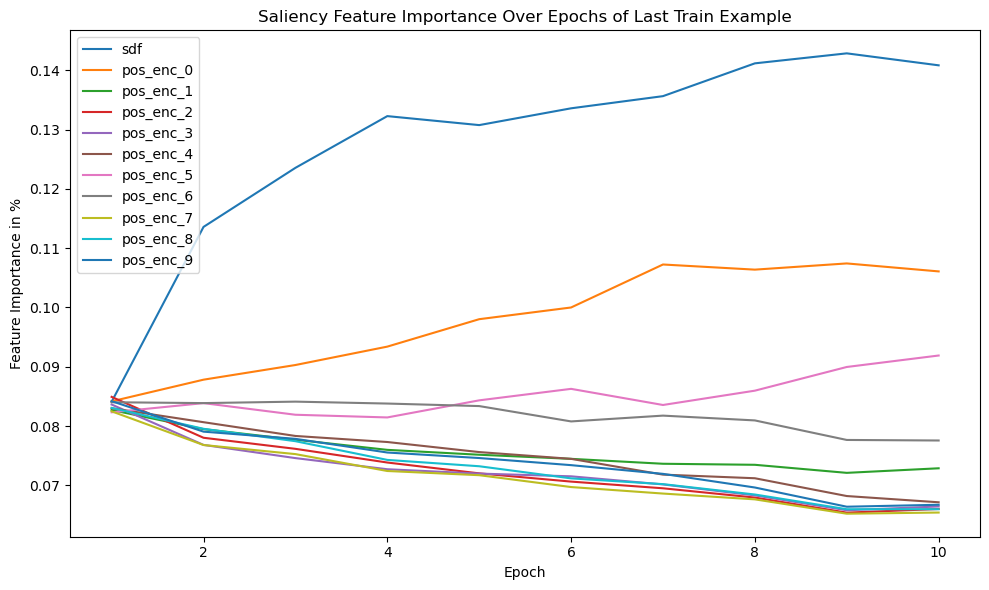

In [25]:
history = train(model, 
                train_data_loader, 
                val_data_loader, 
                optimizer, 
                criterion, 
                epochs=10, 
                device=device)

# Plot

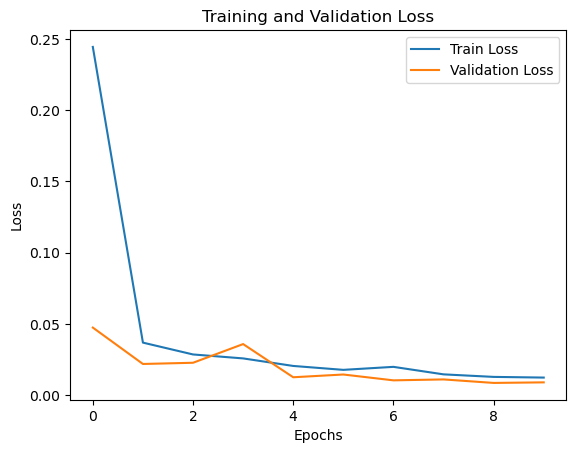

In [26]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [ ]:
# idx = random.randint(0, len(test_dataset)-1)
idx=3
small_sdf, large_sdf, mask, input, actual = test_dataset[idx]
# input = positional_encoding(input, pos_enc_dim).to(device)

# large grid from small VDBTensor
small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                      None, 
                                      mask = mask, 
                                      size=33, mode='test')
# pred = model(input)
steps = 10
for i, t in enumerate(torch.linspace(0.0, 1, steps), start=1):
    print(i,t)
    t = torch.full_like(actual.jdata, t).to(device)
    if i==1:
        xt, noise = transform_input(input, actual, t=t, 
                                    scale_factor=2, 
                                    upsampler='trilinear', 
                                    g_noise=False,
                                    # keep_gt=True,
                                    test=True)
        noise_i = noise
    else:
        xt, noise = transform_input(noise, actual, t=t, 
                                    upsampler=None, 
                                    g_noise=False,
                                    test=True)
        
    pred = model(xt)
    noise = noise.jdata + (1 / steps) * pred.jdata
    noise = fvnn.VDBTensor(xt.grid, xt.grid.jagged_like(noise))

1 tensor(0.)
2 tensor(0.0101)
3 tensor(0.0202)
4 tensor(0.0303)
5 tensor(0.0404)
6 tensor(0.0505)
7 tensor(0.0606)
8 tensor(0.0707)
9 tensor(0.0808)
10 tensor(0.0909)
11 tensor(0.1010)
12 tensor(0.1111)
13 tensor(0.1212)
14 tensor(0.1313)
15 tensor(0.1414)
16 tensor(0.1515)
17 tensor(0.1616)
18 tensor(0.1717)
19 tensor(0.1818)
20 tensor(0.1919)
21 tensor(0.2020)
22 tensor(0.2121)
23 tensor(0.2222)
24 tensor(0.2323)
25 tensor(0.2424)
26 tensor(0.2525)
27 tensor(0.2626)
28 tensor(0.2727)
29 tensor(0.2828)
30 tensor(0.2929)
31 tensor(0.3030)
32 tensor(0.3131)
33 tensor(0.3232)
34 tensor(0.3333)
35 tensor(0.3434)
36 tensor(0.3535)
37 tensor(0.3636)
38 tensor(0.3737)
39 tensor(0.3838)
40 tensor(0.3939)
41 tensor(0.4040)
42 tensor(0.4141)
43 tensor(0.4242)
44 tensor(0.4343)
45 tensor(0.4444)
46 tensor(0.4545)
47 tensor(0.4646)
48 tensor(0.4747)
49 tensor(0.4848)
50 tensor(0.4949)
51 tensor(0.5051)
52 tensor(0.5152)
53 tensor(0.5253)
54 tensor(0.5354)
55 tensor(0.5455)
56 tensor(0.5556)
57 te

In [30]:
def upload_plot_mesh_to_wandb(v, f, title):
    """Upload a mesh to wandb"""
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # Plot the mesh using trisurf
    ax.plot_trisurf(v[:, 0], v[:, 1], v[:, 2], triangles=f, cmap='viridis', edgecolor='none', alpha=0.8)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    
    # Log to wandb
    wandb.log({f'mesh_image: {title}': wandb.Image(fig)})
    plt.close(fig)

In [36]:
v, f = fu.vdb_marching_cubes(small_vdb)
# upload_plot_mesh_to_wandb(v, f, title='small SDF')
plot(v,f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(7.5101852…

In [37]:
v, f = fu.vdb_marching_cubes(noise_i)
# upload_plot_mesh_to_wandb(v, f, title='input: noise at t=0.0')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(7.5101852…

In [38]:
v, f = fu.vdb_marching_cubes(noise)
# upload_plot_mesh_to_wandb(v, f, title='predition')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-7.284432…

In [39]:
v, f = fu.vdb_marching_cubes(actual)
# upload_plot_mesh_to_wandb(v, f, title='GT: large SDF')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(1.3262033…

In [53]:
wandb.finish()

epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▃▂▂▂▁▁▁▁▁
val_loss,█▄▁▂▂▁▂▂▂▂
epoch,9
train_loss,0.00458
val_loss,0.02312
